# Step 3: Geo-intervention Generation

## Libaries

In [42]:
from pathlib import Path
from pickle import dump, load
from pprint import pprint

import modules as geoint
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Folders

Create folders for storing models and related data.

In [7]:
# Set folder for data and models
data_folder = '../../tmp/data'
model_folder = '../../tmp/models'
downloads_folder = '../../tmp/downloads'

# Create folders for model data
Path(data_folder).mkdir(parents=True, exist_ok=True)
Path(model_folder).mkdir(parents=True, exist_ok=True)

## Load Best Model

In [8]:
# Load toronto boundaries for clipping
city = gpd.read_file(f'{downloads_folder}/toronto.geojson')\
    .to_crs(32617)

# Determine best model
scores = pd.read_csv(f'{model_folder}/scores.csv')
opt_model = scores[(scores.metric == 'mean_absolute_error')]\
    .sort_values('score')\
    .iloc[0]\
    .model
opt_model_label = opt_model\
    .replace('_10', ' (10x10)')\
    .replace('_40', ' (40x40)')\
    .replace('_80', ' (80x80)')

# Create dict for best model
models = {}
geodata = {}

# Determine size and model type based on name
model_type = opt_model.split('_')[0]
size = int(opt_model.split('_')[1])
    
# Load data
print(f'Processing geogrid_to_{size}...')
xraw = gpd.read_file(f'{data_folder}/geogrid_to_{size}.geojson')

# Clip data
xraw = xraw.clip(city)

# Drop geometry and set outcome var
x = pd.DataFrame(xraw.drop(columns='geometry'))
ycol = 'collisions_count'
geodata[f'geogrid_to_{size}'] = xraw
    
# Columns to remove from input data
startswith = ['collisions']

# Drop columns except target col
drop = [c for c in x.columns if any(c.startswith(s) for s in startswith) and c != ycol]
x = x.drop(columns=drop)
    
# Load autosklearn model
if model_type == 'autosklearn':
    ask_file = f'{model_folder}/autosklearn_{size}.pkl'
    print(f'Loading autosklearn_{size}...')
    with open(ask_file, 'rb') as f:
        ask = load(f)
    models[opt_model] = ask
    
# Load tpot model
if model_type == 'tpot':
    tpt_file = f'{model_folder}/tpot_{size}.pkl'
    print(f'Loading tpot_{size}...')
    tpt = geoint.models.AutoMLModel('TPOTRegressor')
    with open(tpt_file, 'rb') as f:
        tpt.model = load(f)
    tpt.last_x = x.drop(columns=ycol).select_dtypes('number').fillna(0)
    tpt.last_y = x[ycol]
    tpt.predict()
    models[opt_model] = tpt

print('Done!')

Processing geogrid_to_80...
Loading autosklearn_80...
Done!


## Optimization

In [9]:
# Determine top three infra vars
importances = pd.read_csv(f'{model_folder}/importances.csv')
importances_vars = importances[~importances.variable.str.startswith(('traffic', 'centrelines', 'crime'))]\
    .sort_values('importance_mean', ascending = False)\
    .head(3)\
    .variable\
    .tolist()

# Determine top traffic var
importances_traffic = importances[
    importances.variable.str.startswith(('traffic')) &
    importances.variable.str.endswith(('sum'))
]\
    .sort_values('importance_mean', ascending = False)\
    .head(1)\
    .variable\
    .tolist()[0]

# Create dict for storing opt results
opt_results = {
    'scenario': [],
    'original': [],
    'optimized': [],
    'model': []
}

# Display traffic and infra vars
print(f'''
Traffic Variable
----------------
{importances_traffic}
      
Top Three Infrastructure Variables
----------------------------------
1. {importances_vars[0]}
2. {importances_vars[1]}
3. {importances_vars[2]}
''')


Traffic Variable
----------------
traffic_eb_cars_l_sum
      
Top Three Infrastructure Variables
----------------------------------
1. red_light_cams_count
2. transit_shelters_count
3. wayfind_count



### Scenario 1

Create geo-interventions by optimizing top three infrastructure variables with higher than average traffic.

In [10]:
# Define local constraints
query_traffic = {'query': f'{importances_traffic} >= {importances_traffic}.mean()'}
lconstr1 = {}
lconstr1[importances_vars[0]] = query_traffic
lconstr1[importances_vars[1]] = query_traffic
lconstr1[importances_vars[2]] = query_traffic

# Create optimizer
print(f'Optimizing predictions for {opt_model}...')
opt1_file = f'{model_folder}/{opt_model}_opt1.pkl'
if Path(opt1_file).is_file():
    
    # Load optimizer from saved file
    print(f'Optimizer for {opt_model} exists - loading results...')
    with open(opt1_file, 'rb') as f:
        opt1_results = load(f)
else:
    
    # Run optimizer
    print(f'Running optimization for {opt_model}...')
    opt1 = geoint.optimization.Optimizer(models[opt_model], lconstr1, 'BayesianOptimization', verbose=0, ymax=False)
    opt1.optimize(n_iter=1000, init_points = 100)
    
    # Save results
    print(f'Saving optimization for {opt_model}...')
    opt1_results = {
        'original': [sum(opt1.model.last_y)],
        'optimized': [opt1.optimal_y],
        'optimal': opt1.optimal,
        'optimal_params': opt1.optimal_params,
        'optimal_details': opt1.optimal_details,
        'params': opt1.optimizer_params
    }
    with open(opt1_file, 'wb') as f:
        dump(opt1_results, f)
        
# Store opt results
opt_results['scenario'] += ['Scenario 1: Higher than avg traffic']
opt_results['original'] += opt1_results['original']
opt_results['optimized'] += opt1_results['optimized']
opt_results['model'] += [opt_model]
print('Done!')

Optimizing predictions for autosklearn_80...
Optimizer for autosklearn_80 exists - loading results...
Done!


In [11]:
# Display s1 results
print(f'''
Scenario 1 Results
------------------
Original: {opt1_results['original'][0]}
Optimized: {opt1_results['optimized'][0]}
Difference: {opt1_results['optimized'][0] - opt1_results['original'][0]}
''')


Scenario 1 Results
------------------
Original: 588876.0
Optimized: 629570.894859314
Difference: 40694.894859313965



### Scenario 2

Create geo-interventions by optimizing  top three infrastructure variables with lower than average numbers.

In [37]:
# Define local constraints
lconstr2 = {}
lconstr2[importances_vars[0]] = {'query': f'{importances_vars[0]} < {importances_vars[0]}.mean()'}
lconstr2[importances_vars[1]] = {'query': f'{importances_vars[1]} < {importances_vars[1]}.mean()'}
lconstr2[importances_vars[2]] = {'query': f'{importances_vars[2]} < {importances_vars[2]}.mean()'}

# Create optimizer
print(f'Optimizing predictions for {opt_model}...')
opt2_file = f'{model_folder}/{opt_model}_opt2.pkl'
if Path(opt2_file).is_file():
    
    # Load optimizer from saved file
    print(f'Optimizer for {opt_model} exists - loading results...')
    with open(opt2_file, 'rb') as f:
        opt2_results = load(f)
else:
    
    # Run optimizer
    print(f'Running optimization for {opt_model}...')
    opt2 = geoint.optimization.Optimizer(models[opt_model], lconstr2, 'BayesianOptimization', verbose=0, ymax=False)
    opt2.optimize(n_iter=1000, init_points=100)
    
    # Save results
    print(f'Saving optimization for {opt_model}...')
    opt2_results = {
        'original': [sum(opt2.model.last_y)],
        'optimized': [opt2.optimal_y],
        'optimal': opt2.optimal,
        'optimal_params': opt2.optimal_params,
        'optimal_details': opt2.optimal_details,
        'params': opt2.optimizer_params
    }
    with open(opt2_file, 'wb') as f:
        dump(opt2_results, f)
        
# Store opt results
opt_results['scenario'] += ['Scenario 2: Modify scarce intervention cells']
opt_results['original'] += opt2_results['original']
opt_results['optimized'] += opt2_results['optimized']
opt_results['model'] += [opt_model]
print('Done!')

Optimizing predictions for autosklearn_80...
Running optimization for autosklearn_80...
Saving optimization for autosklearn_80...
Done!


In [40]:
# Display s2 results
print(f'''
Scenario 2 Results
------------------
Original: {opt2_results['original'][0]}
Optimized: {opt2_results['optimized'][0]}
Difference: {opt2_results['optimized'][0] - opt2_results['original'][0]}
''')


Scenario 2 Results
------------------
Original: 588876.0
Optimized: 1365855.4614973068
Difference: 776979.4614973068



574406.4780416507

### Optimization Results

In [7]:
opt_results = pd.DataFrame(opt_results)
opt_results['diff'] = opt_results.optimized - opt_results.original
opt_results

,scenario,original,optimized,model,diff
0,Scenario 1: Higher than avg traffic,588876.0,7.292720e+05,autosklearn_80,140396.022308
1,Scenario 2: Modify scarce intervention cells,588876.0,1.378895e+06,autosklearn_80,790018.866443


## Generated Geo-interventions

In [8]:
# Read data for selected model
gdata = geodata[f'geogrid_to_{size}'].copy()
gcols = importances_vars

# Get optimal parameters
optimalp = {
    'opt1': opt1_results['optimal_params'],
    'opt2': opt2_results['optimal_params'],
}

# Get params used for optimization
opt_params = {
    'opt1': opt1_results['params'],
    'opt2': opt2_results['params']
}
for k in opt_params:
    opt_params[k].index.name = None
    
# Set params to optimal params
for k in opt_params:
    opt_params[k]['value_optimal'] = opt_params[k]['value_orig']
    opt_params[k].loc[optimalp[k].keys(), 'value_optimal'] = list(optimalp[k].values())

In [9]:
# Set data to optimal params
for k in opt_params:
    params = opt_params[k]
    for c in params.column.unique():
        p = params[params.column == c]
        oc = f'{c}_{k}'
        gdata[oc] = gdata[c].copy()
        gdata.loc[p.row, oc] = p.value_optimal.tolist()
        gdata[f'{oc}_diff'] = gdata[oc] - gdata[c]

In [10]:
gdata[[c + '_opt1' for c in gcols] + [ycol]].head(100)

,red_light_cams_count_opt1,transit_shelters_count_opt1,wayfind_count_opt1,collisions_count
2446,0.0,0.0,0.0,0.0
2447,0.0,0.0,0.0,0.0
2569,0.0,0.0,0.0,2.0
2508,0.0,0.0,0.0,0.0
2509,0.0,0.0,0.0,0.0
...,...,...,...,...
1662,0.0,2.0,3.0,286.0
1541,0.0,6.0,0.0,188.0
1724,0.0,1.0,0.0,220.0
1663,0.0,4.0,0.0,164.0


### Optimization Parameters

In [11]:
opt_params['opt1'].head(100)

,column,row,param,value,bounds,value_orig,value_optimal
red_light_cams_count_1533,red_light_cams_count,1533,red_light_cams_count_1533,1.716540,"(0.0, 4.0)",1.0,3.960424
red_light_cams_count_1595,red_light_cams_count,1595,red_light_cams_count_1595,2.742687,"(0.0, 4.0)",0.0,1.159295
red_light_cams_count_1534,red_light_cams_count,1534,red_light_cams_count_1534,3.075649,"(0.0, 4.0)",0.0,2.666083
red_light_cams_count_1474,red_light_cams_count,1474,red_light_cams_count_1474,1.291596,"(0.0, 4.0)",0.0,2.755261
red_light_cams_count_1658,red_light_cams_count,1658,red_light_cams_count_1658,3.947256,"(0.0, 4.0)",1.0,2.933007
...,...,...,...,...,...,...,...
red_light_cams_count_2094,red_light_cams_count,2094,red_light_cams_count_2094,2.951173,"(0.0, 4.0)",0.0,2.551941
red_light_cams_count_2155,red_light_cams_count,2155,red_light_cams_count_2155,1.057059,"(0.0, 4.0)",1.0,0.142058
red_light_cams_count_2156,red_light_cams_count,2156,red_light_cams_count_2156,0.705811,"(0.0, 4.0)",1.0,3.814443
red_light_cams_count_1973,red_light_cams_count,1973,red_light_cams_count_1973,3.114212,"(0.0, 4.0)",0.0,1.667027


In [12]:
len(opt_params['opt1'].index)

1443

In [13]:
opt_params['opt2'].head(100)

,column,row,param,value,bounds,value_orig,value_optimal
red_light_cams_count_2446,red_light_cams_count,2446,red_light_cams_count_2446,0.327099,"(0.0, 4.0)",0.0,1.212983
red_light_cams_count_2447,red_light_cams_count,2447,red_light_cams_count_2447,1.648776,"(0.0, 4.0)",0.0,2.995915
red_light_cams_count_2569,red_light_cams_count,2569,red_light_cams_count_2569,3.958287,"(0.0, 4.0)",0.0,1.398789
red_light_cams_count_2508,red_light_cams_count,2508,red_light_cams_count_2508,0.781298,"(0.0, 4.0)",0.0,3.087825
red_light_cams_count_2509,red_light_cams_count,2509,red_light_cams_count_2509,0.701123,"(0.0, 4.0)",0.0,0.258718
...,...,...,...,...,...,...,...
red_light_cams_count_1602,red_light_cams_count,1602,red_light_cams_count_1602,2.000190,"(0.0, 4.0)",0.0,3.212922
red_light_cams_count_1725,red_light_cams_count,1725,red_light_cams_count_1725,2.545732,"(0.0, 4.0)",0.0,2.977861
red_light_cams_count_1664,red_light_cams_count,1664,red_light_cams_count_1664,1.063425,"(0.0, 4.0)",0.0,2.000029
red_light_cams_count_1542,red_light_cams_count,1542,red_light_cams_count_1542,1.713115,"(0.0, 4.0)",0.0,1.855228


In [14]:
len(opt_params['opt2'].index)

6131

### Geo-intervention Maps

Scenario 1

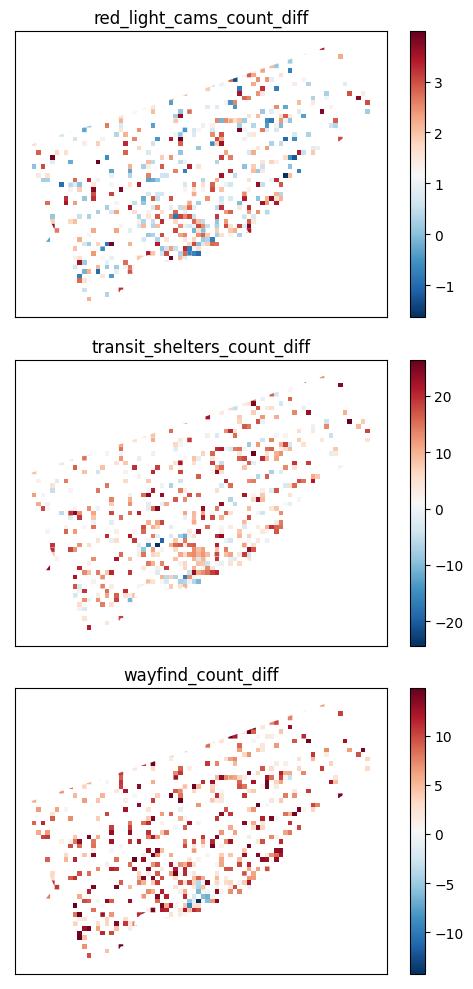

In [15]:
fig = plt.figure()
fig.set_size_inches(5, 10)
pdata = gdata.copy()
pdata.replace(0, np.nan, inplace=True)

# S1 infra 1
ax = plt.subplot(3, 1, 1) # nrows, ncols, axes position
pdata.plot(ax=ax, cmap='RdBu_r', column=f'{importances_vars[0]}_opt1_diff', legend=True)
ax.set_title(f'{importances_vars[0]}_diff')
ax.set_aspect('equal', adjustable='datalim')
ax.axes.get_xaxis().set_visible(False)
ax.axes.get_yaxis().set_visible(False)

# S1 infra 2
ax = plt.subplot(3, 1, 2) # nrows, ncols, axes position
pdata.plot(ax=ax, cmap='RdBu_r', column=f'{importances_vars[1]}_opt1_diff', legend=True)
ax.set_title(f'{importances_vars[1]}_diff')
ax.set_aspect('equal', adjustable='datalim')
ax.axes.get_xaxis().set_visible(False)
ax.axes.get_yaxis().set_visible(False)

# S1 infra 3
ax = plt.subplot(3, 1, 3) # nrows, ncols, axes position
pdata.plot(ax=ax, cmap='RdBu_r', column=f'{importances_vars[2]}_opt1_diff', legend=True)
ax.set_title(f'{importances_vars[2]}_diff')
ax.set_aspect('equal', adjustable='datalim')
ax.axes.get_xaxis().set_visible(False)
ax.axes.get_yaxis().set_visible(False)

plt.tight_layout()
plt.show()

Scenario 2

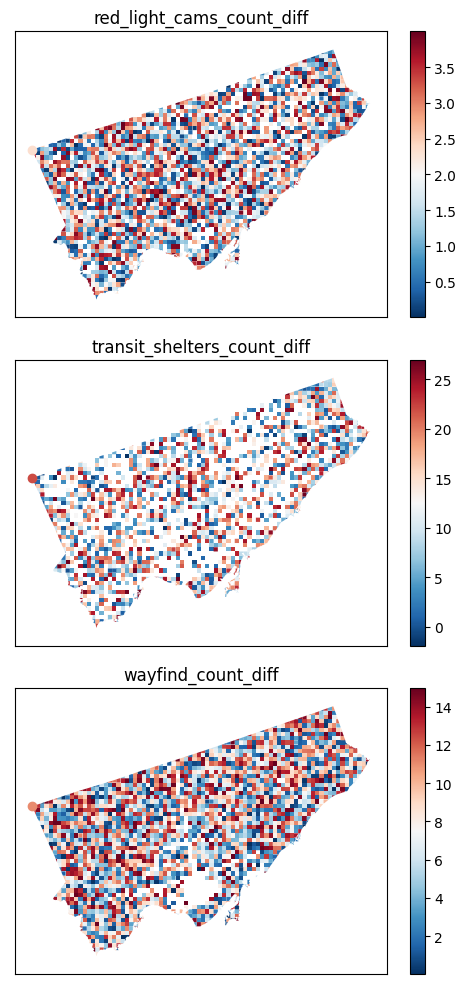

In [16]:
fig = plt.figure()
fig.set_size_inches(5, 10)
pdata = gdata.copy()
pdata.replace(0, np.nan, inplace=True)

# S2 infra 1
ax = plt.subplot(3, 1, 1) # nrows, ncols, axes position
pdata.plot(ax=ax, cmap='RdBu_r', column=f'{importances_vars[0]}_opt2_diff', legend=True)
ax.set_title(f'{importances_vars[0]}_diff')
ax.set_aspect('equal', adjustable='datalim')
ax.axes.get_xaxis().set_visible(False)
ax.axes.get_yaxis().set_visible(False)

# S2 infra 2
ax = plt.subplot(3, 1, 2) # nrows, ncols, axes position
pdata.plot(ax=ax, cmap='RdBu_r', column=f'{importances_vars[1]}_opt2_diff', legend=True)
ax.set_title(f'{importances_vars[1]}_diff')
ax.set_aspect('equal', adjustable='datalim')
ax.axes.get_xaxis().set_visible(False)
ax.axes.get_yaxis().set_visible(False)

# S2 infra 3
ax = plt.subplot(3, 1, 3) # nrows, ncols, axes position
pdata.plot(ax=ax, cmap='RdBu_r', column=f'{importances_vars[2]}_opt2_diff', legend=True)
ax.set_title(f'{importances_vars[2]}_diff')
ax.set_aspect('equal', adjustable='datalim')
ax.axes.get_xaxis().set_visible(False)
ax.axes.get_yaxis().set_visible(False)

plt.tight_layout()
plt.show()